# Лекция 5. Метод Ньютона, квази-ньютоновские методы и Гаусс–Ньютон: локальная сходимость

**Курс:** Вычислительная оптимизация · **Часть II. Безусловная оптимизация и ньютоновские методы** · Лекция 5 из 16 · 7 октября 2026

**Материалы:** [конспект-ноутбук с кодом демонстраций](lecture05.ipynb) · [демо-ноутбук](demo05.ipynb) · [семинар: свой Ньютон и BFGS против SciPy](seminar05.ipynb) · [разбор упражнений](exercises05.ipynb) · [сценарий доски](board05.md)

В конспекте-ноутбуке ячейки демонстраций стоят в тех разделах, к которым относятся (заголовки «Демо (0)»–«Демо (d)»): три задачи — после 1.2, Ньютон на Розенброке — после раздела 3, BFGS — после раздела 4, Гаусс–Ньютон — после раздела 5, биография цепи — после раздела 6. Тот же код отдельно и целиком — `demo05.ipynb`.

---

Лекция 4 закончилась обещанием: градиентный спуск сходится линейно и платит за каждую верную цифру $\sim\kappa$ итераций, а один тизер — метод Ньютона — прошёл Розенброка за $7$ итераций вместо $13\,756$. Сегодня разбираемся, за счёт чего и какой ценой. Три вопроса:

1. Почему Ньютон делает за $7$ шагов то, на что спуску нужно $13\,756$, — и почему при этом его второй шаг улетает в $(0.76,\,-3.18)$?
2. Гессиан — это $n^2$ производных и решение системы $n\times n$ на каждом шаге. Можно ли обойтись без него — *выучить* кривизну по градиентам, которые мы и так считаем?
3. У задач подгонки — суммы квадратов невязок — есть структура. Даёт ли она «почти Ньютона» за цену одного градиента?

Все три ответа — про одну вещь: **квадратичную модель** $m_k(p)$ функции в текущей точке. Ньютон ей верит целиком, квази-Ньютон строит её по кусочкам из градиентов, Гаусс–Ньютон берёт ту её часть, которая у МНК почти бесплатна. Главный герой лекции — эта модель и моменты, когда она **врёт**.

> **Код в этом ноутбуке.** Демонстрации из [`demo05.ipynb`](demo05.ipynb) вставлены в те разделы, к которым относятся; заголовки — «Демо (0)»–«Демо (d)». При чтении их можно пропускать, на лекции — запускать по ходу. Вспомогательный код (палитра, методы `gd`, `newton`, `newton_damped`, `bfgs`, `gauss_newton`, задачи и рисовальщики) вынесен в [`l5helpers.py`](l5helpers.py); его подключает ячейка ниже.

In [1]:
%matplotlib inline

from l5helpers import *  # палитра, методы, задачи, рисовальщики (см. файл рядом)

## 1. Повторение и мост: от линейной модели к квадратичной

### 1.1. Что уже умеем

| Вопрос | Ответ | Где |
|---|---|---|
| Как узнать минимум? | $\nabla f(x^\ast)=0$ необходимо; $\nabla^2f(x^\ast)\succ0$ — достаточно для строгого локального минимума; седло тоже стационарно | Л4, §2–3 |
| Куда шагать и на сколько? | против градиента; шаг $\alpha<2/L$ безопасен, backtracking подбирает его сам | Л4, §4 |
| Сколько итераций? | $\approx\kappa\ln(1/\varepsilon)$ — линейная сходимость с множителем $1-1/\kappa$; Розенброк $\kappa=2508$, цепь $N=40$ — $\kappa=681$ | Л4, §5 |
| Какие бывают скорости? | линейная — прямая на графике $\log\lVert e_k\rVert$; сверхлинейная — всё круче; квадратичная — цифры удваиваются | Л4, §6 |
| Что такое шаг Ньютона? | минимум квадратичной модели: $p_k=-\nabla^2f(x_k)^{-1}\nabla f(x_k)$; на квадратичной функции — одна итерация | Л4, §7 |

### 1.2. Три задачи на сегодня

<img src="img/00_hooks.png" width="900" alt="три задачи: Розенброк с путями спуска и Ньютона, подгонка синуса из ДЗ 2, цепь без пола">

**Розенброк** (Л4, §1.2), старт $(-1.2,\,1)$. Спуск с backtracking — $13\,756$ итераций, Ньютон — $7$. Но посмотрите на путь Ньютона: вторая итерация уводит из долины в $(0.76,\,-3.18)$, ошибка *растёт* вдвое, и лишь с четвёртого шага начинается обрыв. К концу лекции мы будем знать, почему оба факта — и $7$, и выброс — следствия одной формулы.

**Подгонка синуса** (ДЗ 2, задача 2(б)). Те же $60$ измерений $y_i=2\sin(3t_i+0.7)+\varepsilon_i$ и та же невыпуклая модель $\varphi(t;x)=x_1\sin(x_2t+x_3)$. Это **нелинейный МНК**: $f(x)=\tfrac12\sum_i r_i(x)^2$. Из старта $(1,\,3,\,0)$ градиентный спуск доползает до $f^\ast=1.1393$ за $731$ итерацию, Гаусс–Ньютон — за $7$, а чистый метод Ньютона… сходится за $9$ итераций в точку с $x_1=0$ — к модели «ноль», которая не описывает данные вовсе. Ньютон не ошибся: он честно нашёл стационарную точку. Не ту.

**Цепь без пола** (Л1, §7.3; Л4, §1.2). $N=40$ грузов, $80$ переменных, выпуклая квадратичная энергия. В лекции 1 её решил солвер, в лекции 4 — спуск за $10\,575$ итераций. Сегодня она станет мерилом для всех методов: Ньютон решает её одной линейной системой, а чем ответят BFGS и L-BFGS — увидим в разделе 6.

### Демо (0). Три задачи-крючка

Раздел 1 конспекта. Здесь только определяем задачи и смотрим на данные; числа конспекта, которые проверим в частях (a)–(d): Розенброк — спуск $13\,756$, Ньютон $7$, демпфированный Ньютон $22$, BFGS $34$; синус — Гаусс–Ньютон $7$, спуск $731$, Ньютон уходит в $x_1=0$; цепь — спуск $10\,575$, Ньютон $1$, BFGS $20$.

**Задача А. Розенброк** $f(x)=(1-x_1)^2+100(x_2-x_1^2)^2$, старт $(-1.2,\,1)$ — как в лекции 4. Гессиан $\begin{pmatrix}2-400x_2+1200x_1^2&-400x_1\\-400x_1&200\end{pmatrix}$; его определитель $80\,000\,(x_1^2-x_2+0.005)$ — отрицателен над параболой $x_2=x_1^2+0.005$, и там квадратичная модель седловая.

f(x0) = 24.2   grad = [-215.6  -88. ]   собственные числа гессиана: [  23.63 1506.37]
точка [-1.2, 1.0]: det H = 35600 (формула 35600) -> положительно определён
точка [0.0, 1.0]: det H = -79600 (формула -79600) -> индефинитен
точка [1.0, 1.0]: det H = 400 (формула 400) -> положительно определён


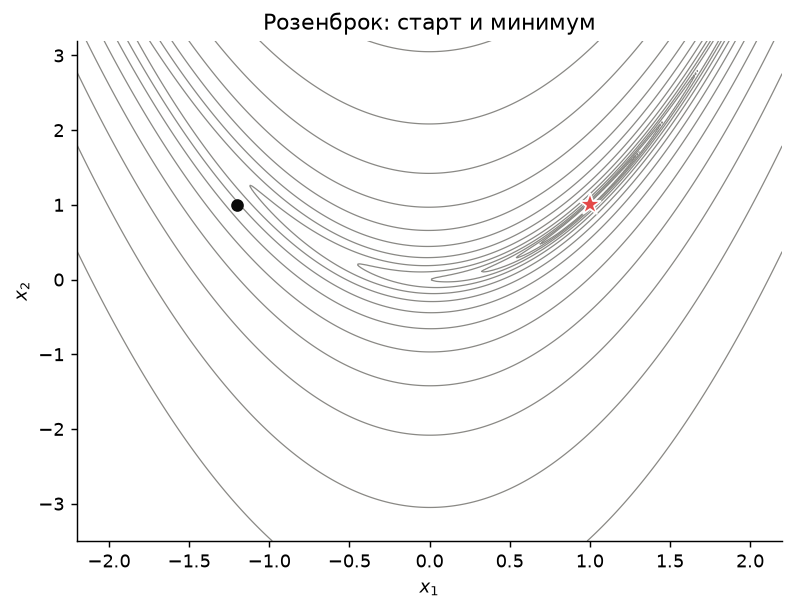

In [2]:
x = X0_ROSEN
print("f(x0) =", round(rosen(x), 2), "  grad =", rosen_grad(x).round(2), "  собственные числа гессиана:", np.linalg.eigvalsh(rosen_hess(x)).round(2))
for pt in ([-1.2, 1.0], [0.0, 1.0], [1.0, 1.0]):
    H = rosen_hess(np.array(pt)); d = np.linalg.det(H); formula = 80_000 * (pt[0] ** 2 - pt[1] + 0.005)
    print(f"точка {pt}: det H = {d:.0f} (формула {formula:.0f}) -> {'положительно определён' if d > 0 else 'индефинитен'}")
plot_rosen_path([], ax=None).plot(*X0_ROSEN, "o", color=INK)
plt.title("Розенброк: старт и минимум"); plt.show()

**Задача Б. Подгонка синуса** (ДЗ 2, задача 2(б)). Данные генерируются тем же `default_rng(2026)` и в том же порядке, что в ноутбуке ДЗ, поэтому совпадают с ним точно. Модель $\varphi(t;x)=x_1\sin(x_2t+x_3)$, невязки $r_i=\varphi(t_i;x)-y_i$, цель $f=\tfrac12\lVert r\rVert^2$. Проверяем формулы $\nabla f=J^\top r$ и $\nabla^2f=J^\top J+\sum r_i\nabla^2r_i$ конечными разностями.

градиент: аналитический [   9.0231 -221.2442  -69.1056]  конечные разности [   9.0231 -221.2442  -69.1056]
гессиан:  max |аналитический - разностный| = 0.0
старт ДЗ 2 №1: [-1.863 -3.822  1.632]   всего стартов: 20


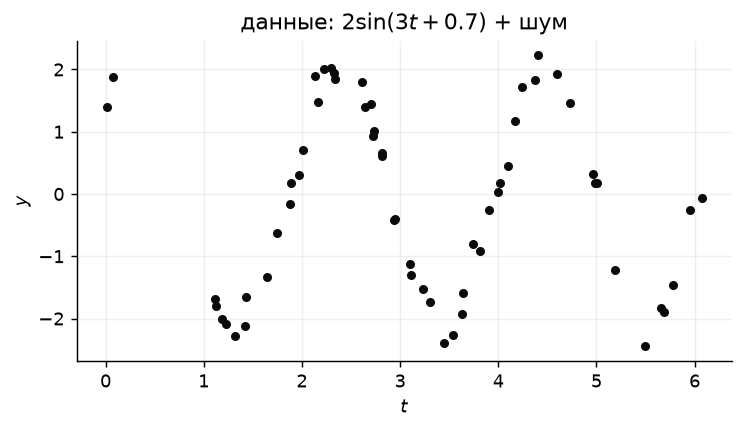

In [3]:
t, y, starts = sine_data()
resid, jac, f_s, grad_s, hess_s = sine_problem(t, y)
x = np.array([1.5, 2.8, 0.4]); h = 1e-6
g_fd = np.array([(f_s(x + h * e) - f_s(x - h * e)) / (2 * h) for e in np.eye(3)])
H_fd = np.array([(grad_s(x + h * e) - grad_s(x - h * e)) / (2 * h) for e in np.eye(3)])
print("градиент: аналитический", grad_s(x).round(4), " конечные разности", g_fd.round(4))
print("гессиан:  max |аналитический - разностный| =", np.abs(hess_s(x) - H_fd).max().round(5))
print("старт ДЗ 2 №1:", starts[0].round(3), "  всего стартов:", len(starts))
plt.figure(figsize=(6.5, 3.2)); plt.plot(t, y, "o", ms=4, color=INK); plt.xlabel("$t$"); plt.ylabel("$y$"); plt.title("данные: $2\\sin(3t+0.7)$ + шум"); plt.show()

**Задача В. Цепь без пола** (лекция 1, §7.3; лекция 4, демо (d)). $N=40$ грузов, $80$ переменных, энергия квадратична: $\nabla E=Hv+b$, $\nabla^2E=H=\operatorname{diag}(DK,DK)$. Проверяем, что `grad_E` — действительно градиент `energy`, и запоминаем точное решение `np.linalg.solve(H, -b)` — с ним будем сравнивать все методы.

In [4]:
energy, grad_E, H_chain, b_chain, v0_chain, unpack = make_chain(40)
v_test = np.random.default_rng(0).normal(size=80); h = 1e-6
g_fd = np.array([(energy(v_test + h * e) - energy(v_test - h * e)) / (2 * h) for e in np.eye(80)])
print("проверка градиента цепи: max |grad_E - разности| =", np.abs(grad_E(v_test) - g_fd).max().round(6))
v_star = np.linalg.solve(H_chain, -b_chain)
lam = np.linalg.eigvalsh(H_chain)
print(f"E* = {energy(v_star):.4f} (в конспекте 13.4417),  κ = {lam[-1] / lam[0]:.1f} (в конспекте 681),  L = {lam[-1]:.1f}")

проверка градиента цепи: max |grad_E - разности| = 1e-06
E* = 13.4417 (в конспекте 13.4417),  κ = 680.6 (в конспекте 681),  L = 279.6


### 1.3. Что сегодня

Метод Ньютона как минимизация квадратичной модели и как решение системы $\nabla f=0$ (раздел 2) → локальная квадратичная сходимость и её граница: бассейны, седловые модели, демпфирование (3) → секущее уравнение, BFGS и L-BFGS (4) → Гаусс–Ньютон и Левенберг–Марквардт для МНК (5) → сравнение методов на трёх задачах (6). Семинар — за ноутбуком: пишем Ньютона и BFGS сами и сравниваем со SciPy (раздел 10).

## 2. Метод Ньютона: поверить квадратичной модели

### 2.1. Модель и шаг

В лекции 4 (§7) мы заменили функцию вблизи $x_k$ её разложением Тейлора второго порядка:

$$
m_k(p)=f(x_k)+\nabla f(x_k)^\top p+\tfrac12\,p^\top\nabla^2f(x_k)\,p .
$$

Градиентный спуск пользуется только линейной частью этой модели и добавляет шаг «снаружи» — через $\alpha$. Ньютон доверяет модели целиком: следующая точка — её минимум. Если $H_k=\nabla^2f(x_k)\succ0$, минимум модели единственный, $\nabla m_k(p)=g_k+H_kp=0$, и

$$
\boxed{\;x_{k+1}=x_k+p_k,\qquad H_k\,p_k=-g_k\;}
$$

Длина шага *не выбирается*: модель сама говорит, куда и на сколько. В этом сила метода и его слабость.

<img src="img/01_quadratic_model.png" width="900" alt="Розенброк: эллипсы квадратичной модели в стартовой точке и во второй итерации Ньютона против линий уровня функции">

На картинке линии уровня Розенброка (серые) и линии уровня модели $m_k$ (оранжевые эллипсы) в двух точках пути Ньютона. У старта $(-1.2,1)$ модель ещё похожа на функцию, и шаг разумный. Во второй точке модель — вытянутый эллипс, минимум которого лежит далеко за пределами долины: шаг в $(0.76,-3.18)$ — это честный минимум модели, которая здесь уже не имеет отношения к функции. **Ньютон ошибается ровно там, где врёт модель.**

### 2.2. Второе прочтение: решаем систему $\nabla f=0$

Условие минимума — $n$ уравнений $\nabla f(x)=0$ с $n$ неизвестными. Линеаризуем левую часть в точке $x_k$:

$$
\nabla f(x_k+p)\approx\nabla f(x_k)+\nabla^2f(x_k)\,p=0\quad\Longrightarrow\quad p=-\nabla^2f(x_k)^{-1}\nabla f(x_k).
$$

Тот же шаг. Это **метод Ньютона для нелинейных систем**, знакомый по одномерному $x_{k+1}=x_k-F(x_k)/F'(x_k)$: касательная к графику $F=\nabla f$ пересекает ось — там следующая точка. Второе прочтение честнее первого: оно не делает вид, что ищет минимум. Метод ищет **нуль градиента** — а это и минимум, и максимум, и седло. Отсюда синус из крючка: точка с $x_1=0$ — стационарная, и Ньютон ею вполне доволен.

### 2.3. Одна переменная: парабола едет по функции

$f(x)=\ln\cosh x$ — гладкая чаша с минимумом в нуле, но с *убывающей* кривизной: $f''=1/\cosh^2x\to0$ на бесконечности. В точке $x_k$ модель — парабола с той же высотой, наклоном и кривизной; следующая точка — её вершина:

$$
x_{k+1}=x_k-\frac{f'(x_k)}{f''(x_k)}=x_k-\tanh x_k\cosh^2x_k=x_k-\tfrac12\sinh 2x_k .
$$

<img src="img/02_newton_1d.png" width="900" alt="ln cosh x: касательные параболы и шаги Ньютона из 0.9 (сходится) и из 1.2 (перелёт и расходимость)">

Из $x_0=0.9$ парабола стоит почти там же, где функция: ошибки $0.57,\ 0.13,\ 1.6\cdot10^{-3},\ 2.5\cdot10^{-9}$ — четыре шага, и мы на дне. Из $x_0=1.2$ кривизна в точке мала, парабола широкая, её вершина перелетает через нуль дальше, чем мы были, — и с каждым шагом дальше: $1.2\to-1.53\to3.82\to-516$. Граница между двумя исходами — точка $x_0\approx1.0886$, где шаг переносит ровно в $-x_0$: метод застревает в 2-цикле.

<img src="img/09_parabola_rides.gif" width="900" alt="анимация: старт Ньютона на ln cosh x движется от 0.3 до 1.3; до порога 1.0886 парабола-модель за три шага приводит в нуль, после — вершина параболы перелетает всё дальше">

На анимации старт $x_0$ ползёт слева направо; видно, как парабола-модель становится всё шире, а её вершина — всё дальше от минимума, пока в $1.0886$ метод не перестаёт сходиться. Это и есть «модель врёт»: вдали от минимума вторая производная в точке ничего не знает о функции в целом.

### 2.4. Аффинная инвариантность: почему Ньютону всё равно, какое $\kappa$

Замена координат $x=Au$ с невырожденной $A$ переводит $f$ в $\tilde f(u)=f(Au)$; тогда $\nabla\tilde f=A^\top\nabla f$, $\nabla^2\tilde f=A^\top\nabla^2f\,A$, и шаг Ньютона в новых координатах

$$
\tilde p=-(A^\top HA)^{-1}A^\top g=-A^{-1}H^{-1}A^{-\top}A^\top g=A^{-1}p .
$$

Шаг в $u$-координатах — это ровно тот же шаг $p$, пересчитанный в новые координаты: $A\tilde p=p$. Метод Ньютона **не замечает** замены переменных: путь итераций в исходных координатах один и тот же, что бы мы ни взяли за единицы измерения. У градиентного спуска всё наоборот — замена $u_2=5x_2$ меняла число итераций с $378$ на $1$ (Л4, §5.4). Число обусловленности — свойство координат, а Ньютон координат не видит; поэтому $\kappa=2508$ Розенброка ему безразлично.

**Одной строкой.** Шаг Ньютона — минимум квадратичной модели и одновременно нуль линеаризованного градиента; он не зависит от координат, но верит модели там, где она уже врёт.

## 3. Локальная сходимость: обрыв и его граница

### 3.1. Теорема о квадратичной сходимости

Пусть $\nabla f(x^\ast)=0$, $\nabla^2f(x^\ast)\succ0$, и в окрестности $x^\ast$ гессиан липшицев: $\lVert\nabla^2f(x)-\nabla^2f(y)\rVert\le M\lVert x-y\rVert$, а $\nabla^2f(x)\succeq mI$ с $m>0$. Тогда для итераций Ньютона, начатых достаточно близко к $x^\ast$,

$$
\boxed{\;\lVert e_{k+1}\rVert\le\frac{M}{2m}\,\lVert e_k\rVert^2\;}
$$

*Доказательство.* Пусть $H_k=\nabla^2f(x_k)$, $e_k=x_k-x^\ast$. Шаг: $e_{k+1}=e_k-H_k^{-1}g_k=H_k^{-1}\big(H_ke_k-g_k\big)$. Так как $g(x^\ast)=0$, по формуле Ньютона–Лейбница $g_k=\int_0^1\nabla^2f(x^\ast+te_k)\,e_k\,dt$, и

$$
H_ke_k-g_k=\int_0^1\big(\nabla^2f(x_k)-\nabla^2f(x^\ast+te_k)\big)e_k\,dt,
\qquad
\lVert H_ke_k-g_k\rVert\le\int_0^1M(1-t)\lVert e_k\rVert^2dt=\tfrac M2\lVert e_k\rVert^2 .
$$

Осталось $\lVert H_k^{-1}\rVert\le1/m$. $\square$

Идея в одной фразе: *ошибка Ньютона — это ошибка модели*: разность между гессианом в точке и гессианом «по пути», а она квадратична по $\lVert e_k\rVert$, потому что гессиан меняется не быстрее чем линейно.

### 3.2. Что видно: цифры удваиваются

Если $C\lVert e_0\rVert<1$ при $C=M/2m$, то $C\lVert e_k\rVert\le(C\lVert e_0\rVert)^{2^k}$: число верных цифр удваивается на каждом шаге. Розенброк из $(-1.2,1)$:

| $k$ | 0 | 1 | 2 | 3 | 4 | 5 | 6 |
|---|---|---|---|---|---|---|---|
| $\lVert e_k\rVert$ | $2.2$ | $2.21$ | $4.18$ | $0.48$ | $0.056$ | $9.6\cdot10^{-6}$ | $1.9\cdot10^{-11}$ |
| $\lVert e_{k+1}\rVert/\lVert e_k\rVert^2$ | $0.46$ | $0.86$ | $0.027$ | $0.24$ | $0.003$ | $0.2$ | — |

Три фазы. Итерации 0–2: ошибка не убывает, модель врёт. Итерации 3–4: ошибка уже меньше единицы и начинает падать. С пятой — обрыв: $0.056\to10^{-5}\to10^{-11}$, по $C_k$ в пределах $0.003$–$0.24$. Оценка теоремы здесь грубая: замеренные около $(1,1)$ $M\approx3100$ и $m\approx0.4$ дают $C\approx3900$ и гарантируют сходимость лишь из шара радиуса $3\cdot10^{-4}$ — а на деле метод сошёлся из точки на расстоянии $2.2$. Так обычно и бывает: теорема описывает *тип* сходимости, а не область.

<img src="img/03_rates_four.png" width="900" alt="Розенброк из (-1.2, 1): логарифм ошибки для градиентного спуска, Ньютона с backtracking, чистого Ньютона и BFGS">

Четыре метода на одном графике — главный диагностический рисунок курса. Спуск — прямая (линейная сходимость, $13\,756$ итераций). Чистый Ньютон — $7$ итераций с горбом в начале и обрывом в конце. Ньютон с подбором шага (§3.4) — $22$ итерации, без горба, но и обрыв позже. BFGS (раздел 4) — $34$ итерации: кривая загибается всё круче, но не так резко, как у Ньютона, — это сверхлинейная сходимость.

### 3.3. Локальность: бассейны притяжения

Теорема обещает сходимость только из окрестности. Что снаружи? Ньютон идёт к *ближайшему в смысле модели* нулю градиента — не обязательно к минимуму и не обязательно к ближайшему геометрически.

<img src="img/04_basins.png" width="900" alt="функция Химмельблау: каждая стартовая точка сетки окрашена по тому, в какую из девяти стационарных точек пришёл чистый метод Ньютона">

Функция Химмельблау $f=(x_1^2+x_2-11)^2+(x_1+x_2^2-7)^2$ имеет девять стационарных точек: четыре минимума ($f=0$), четыре седла и один локальный максимум. Каждая точка сетки $300\times300$ на $[-6,6]^2$ окрашена по тому, куда пришёл чистый Ньютон. Сходится практически отовсюду (медиана — $6$ итераций), но в минимум — только $64\,\%$ стартов; $31\,\%$ приходят в сёдла, $4\,\%$ — в максимум. Границы бассейнов изрезаны: соседние старты уходят в разные точки. Это цена второго прочтения из §2.2: метод решает $\nabla f=0$ и не отличает чашу от перевала.

Покрутить руками — старт, метод и бассейны — можно на [интерактивной странице](https://claude.ai/artifact/9NaEBdf8cjpnMbYEdW8Zy2) (исходник — [`interactive/05_newton_vs_descent.html`](interactive/05_newton_vs_descent.html)): сцена «Ньютон против спуска» на Розенброке с табло $13\,756$ / $7$ / $22$ / $34$, сцена «Бассейны» на Химмельблау и парабола из §2.3 с ползунком старта.

### 3.4. Ньютон — не метод спуска, и как это чинят

Направление $p$ — направление спуска, если $g^\top p<0$. Для шага Ньютона $g^\top p=-g^\top H^{-1}g$, и знак определяется матрицей $H^{-1}$:

- $H\succ0$ — спуск гарантирован: $g^\top H^{-1}g>0$;
- $H$ индефинитна — модель седловая (Л4, §3, таблица ландшафтов), у неё нет минимума, а «решение» $Hp=-g$ ведёт в её седло, возможно *вверх* по $f$;
- $H$ вырождена — шага нет вовсе.

<img src="img/05_descent_or_not.png" width="900" alt="Розенброк: светлым выделена область индефинитного гессиана над параболой x2 = x1^2 + 0.005, тёмным — узкая полоса, где шаг Ньютона идёт вверх; в пяти точках показаны антиградиент и шаг Ньютона">

У Розенброка $\det\nabla^2f=80\,000\,(x_1^2-x_2+0.005)$, то есть $\det\nabla^2f<0\iff x_2>x_1^2+0.005$. Вся область *над* дном долины — индефинитная (почти половина картинки). Но «индефинитна» не значит «шаг вверх»: там модель седловая, шаг $Hp=-g$ ведёт в её седло, и для большинства точек это всё ещё направление вниз по $f$ — просто без всяких гарантий. Вверх шаг смотрит в узкой полосе сразу над дном долины (тёмная полоса на картинке, меньше процента окна): там $\det\nabla^2f$ близок к нулю, $H^{-1}$ огромна, и направление задаёт почти вырожденная матрица. Старт $(-1.2,1)$ лежит под параболой ($1<1.445$), поэтому первый шаг — спуск; выброс итерации 2 случился не из-за индефинитности (в $x_1$ собственные числа $0.34$ и $1307$, обе положительны), а потому, что модель вытянута и её минимум далеко.

Три лекарства, каждое — тема лекции 6, здесь по фразе:

| Лекарство | Идея | Что даёт на Розенброке |
|---|---|---|
| **демпфирование** (*damped Newton*) | направление Ньютона, длина — backtracking по Армихо, как у спуска (Л4, §4.5) | $22$ итерации вместо $7$, зато $f$ убывает на каждом шаге и выброса нет |
| **регуляризация** $H+\tau I$ | сдвинуть собственные числа, пока матрица не станет $\succ0$; при $\tau\to\infty$ шаг стремится к градиентному | мост к Левенбергу–Марквардту (§5.5) |
| **доверительная область** (*trust region*) | минимизировать модель только в шаре радиуса $\Delta_k$, где ей ещё верим | лекция 6 |

Демпфирование — самое простое: мы уже знаем, что шаг Ньютона — направление спуска при $H\succ0$, значит, backtracking из лекции 4 к нему применим без изменений. Платим итерациями вдали от минимума; вблизи Армихо принимает $\alpha=1$ сразу, и квадратичная сходимость возвращается (упражнение 11.4).

**Одной строкой.** Вблизи минимума Ньютон удваивает число верных цифр за шаг; вдали он решает $\nabla f=0$ и может прийти в седло или уйти вверх — чинят это подбором длины шага.

### Демо (a). Метод Ньютона на Розенброке

Разделы 2–3 конспекта. **Что проверяем.** Чистый Ньютон из $(-1.2,1)$ сходится за $7$ итераций до $\lVert\nabla f\rVert\le10^{-10}$; ошибки $2.2,\ 2.21,\ 4.18,\ 0.48,\ 0.056,\ 9.6\cdot10^{-6},\ 1.9\cdot10^{-11}$ — на итерации 2 ошибка *растёт* (точка улетает в $(0.76,-3.18)$), с пятой — обрыв. Отношения $C_k=\lVert e_{k+1}\rVert/\lVert e_k\rVert^2$ в хвосте — порядка $0.003$–$0.2$, много меньше теоретической оценки $M/2m\approx3000$.

In [5]:
x_n, k_n, path_n = newton(rosen_grad, rosen_hess, X0_ROSEN)
err_n = np.linalg.norm(path_n - 1, axis=1)
print(f"Ньютон: {k_n} итераций (в конспекте 7), x = {x_n}")
print(" k   x_k                     |e_k|      |e_{k+1}|/|e_k|^2   lambda(H(x_k))")
for k in range(len(path_n)):
    ratio = f"{err_n[k + 1] / err_n[k] ** 2:9.3f}" if k + 1 < len(path_n) and err_n[k] > 0 else "        -"
    lam = np.linalg.eigvalsh(rosen_hess(path_n[k]))
    print(f"{k:2d}  ({path_n[k, 0]: .5f}, {path_n[k, 1]: .5f})   {err_n[k]:.2e}   {ratio}      {lam[0]:8.2f} {lam[1]:9.1f}" + ("   <- ошибка выросла" if k > 0 and err_n[k] > err_n[k - 1] else ""))

Ньютон: 7 итераций (в конспекте 7), x = [1. 1.]
 k   x_k                     |e_k|      |e_{k+1}|/|e_k|^2   lambda(H(x_k))
 0  (-1.20000,  1.00000)   2.20e+00       0.456         23.63    1506.4
 1  (-1.17528,  1.38067)   2.21e+00       0.857          0.34    1306.9   <- ошибка выросла
 2  ( 0.76311, -3.17503)   4.18e+00       0.027        148.86    2022.0   <- ошибка выросла
 3  ( 0.76343,  0.58282)   4.80e-01       0.243          0.60     667.7
 4  ( 1.00000,  0.94403)   5.60e-02       0.003          4.78    1019.6
 5  ( 1.00000,  0.99999)   9.62e-06       0.200          0.40    1001.6
 6  ( 1.00000,  1.00000)   1.85e-11       0.000          0.40    1001.6
 7  ( 1.00000,  1.00000)   0.00e+00           -          0.40    1001.6


Гессиан положительно определён во всех семи точках пути — выброс итерации 2 не связан с индефинитностью: просто в $x_1$ модель вытянута, и её минимум далеко от долины (конспект, §2.1, картинка 01).

**Где шаг Ньютона — не спуск.** Знак $g^\top p=-g^\top H^{-1}g$ зависит от $H$. Проверяем в нескольких точках: под параболой $x_2=x_1^2+0.005$ гессиан $\succ0$ и шаг — спуск; над ней модель седловая, и шаг обычно всё ещё вниз (в седло модели), но в узкой полосе сразу над дном долины $g^\top p>0$ — подъём.

In [6]:
for pt in ([-1.7, 1.2], [-1.06, 1.18], [1.0, 2.6], [0.5, -0.6], [0.0, 1.0]):
    x = np.array(pt); g = rosen_grad(x); H = rosen_hess(x); p = -np.linalg.solve(H, g)
    print(f"точка {pt}: det H = {np.linalg.det(H):9.0f},  g^T p = {g @ p:9.2f}  -> {'спуск' if g @ p < 0 else 'ПОДЪЁМ: f растёт вдоль шага Ньютона'}")

# доля точек окна [-2.2, 2.2] x [-1.2, 4.2], где гессиан индефинитен и где шаг идёт вверх
X, Y = np.meshgrid(np.linspace(-2.2, 2.2, 221), np.linspace(-1.2, 4.2, 271))
G1 = -2 * (1 - X) - 400 * X * (Y - X ** 2); G2 = 200 * (Y - X ** 2)
Hxx = 2 - 400 * Y + 1200 * X ** 2; Hxy = -400 * X; det = Hxx * 200 - Hxy ** 2
P1 = -(200 * G1 - Hxy * G2) / det; P2 = -(Hxx * G2 - Hxy * G1) / det
print(f"гессиан индефинитен на {(det < 0).mean():.0%} окна; шаг Ньютона идёт вверх на {((G1 * P1 + G2 * P2) > 0).mean():.1%} окна")

точка [-1.7, 1.2]: det H =    135600,  g^T p =   -571.26  -> спуск
точка [-1.06, 1.18]: det H =     -4112,  g^T p =      0.19  -> ПОДЪЁМ: f растёт вдоль шага Ньютона
точка [1.0, 2.6]: det H =   -127600,  g^T p =   -512.00  -> спуск
точка [0.5, -0.6]: det H =     68400,  g^T p =   -144.50  -> спуск
точка [0.0, 1.0]: det H =    -79600,  g^T p =   -199.99  -> спуск
гессиан индефинитен на 48% окна; шаг Ньютона идёт вверх на 0.6% окна


**Демпфирование.** То же направление, но длина шага — backtracking по Армихо, как у спуска в лекции 4. Должны увидеть $22$ итерации: $f$ убывает на каждом шаге и выброса нет (ошибка по пути не превышает $2.21$ против $4.18$ у чистого Ньютона), зато обрыв начинается позже (вблизи минимума Армихо принимает $\alpha=1$, и метод снова чистый Ньютон).

демпфированный Ньютон: 22 итераций (в конспекте 22), x = [1. 1.];  f убывает на каждом шаге: True;  наибольшая ошибка по пути 2.208 (у чистого Ньютона 4.18)
ошибки: [2.200e+00 2.208e+00 1.942e+00 1.829e+00 1.711e+00 1.632e+00 1.565e+00 1.473e+00 1.335e+00 1.226e+00 1.078e+00
 9.376e-01 6.957e-01 5.893e-01 4.164e-01 2.919e-01 1.320e-01 7.126e-02 9.180e-03 1.173e-03 2.727e-06 1.351e-10
 0.000e+00]


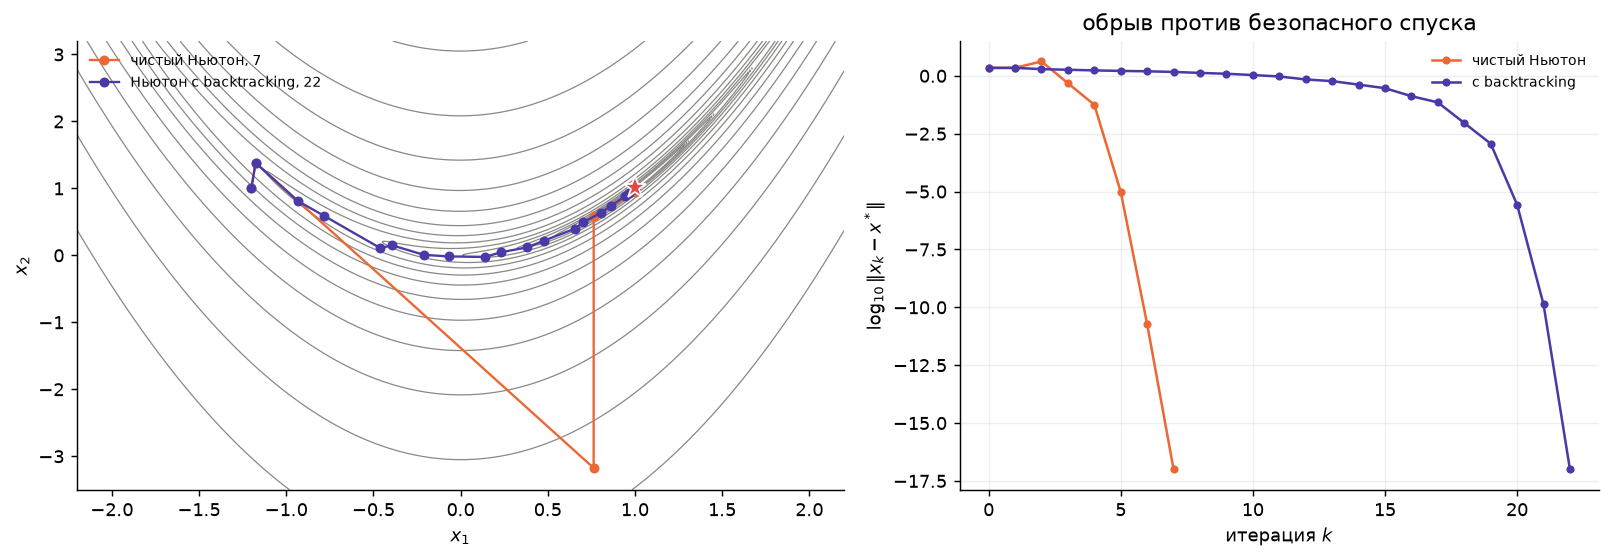

In [7]:
x_d, k_d, path_d = newton_damped(rosen, rosen_grad, rosen_hess, X0_ROSEN)
err_d = np.linalg.norm(path_d - 1, axis=1)
f_d = np.array([rosen(v) for v in path_d])
print(f"демпфированный Ньютон: {k_d} итераций (в конспекте 22), x = {x_d.round(8)};  f убывает на каждом шаге: {np.all(np.diff(f_d) < 0)};  наибольшая ошибка по пути {err_d.max():.3f} (у чистого Ньютона 4.18)")
print("ошибки:", np.array2string(err_d, precision=3, max_line_width=120))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.4), gridspec_kw={"width_ratios": [1.2, 1]})
plot_rosen_path([path_n, path_d], [f"чистый Ньютон, {k_n}", f"Ньютон с backtracking, {k_d}"], ax=ax1)
plot_errors([err_n, err_d], ["чистый Ньютон", "с backtracking"], ax=ax2)
ax2.set_title("обрыв против безопасного спуска"); plt.tight_layout(); plt.show()

**Предскажите до запуска.** Чистый Ньютон стартует из $(2,2)$ — точки под параболой, где гессиан $\succ0$ с $\kappa\approx108$. Сколько будет итераций: больше или меньше семи? А из $(0,0)$, где функция почти квадратична вдоль $x_2$ ($\lambda=2$ и $200$)? Измените `START` и проверьте.

In [8]:
START = (2.0, 2.0)          # измените и перезапустите; ответ — в следующей ячейке
x, k, path = newton(rosen_grad, rosen_hess, START)
print(f"из {START}: {k} итераций, ошибки {np.array2string(np.linalg.norm(path - 1, axis=1), precision=2)}")

из (2.0, 2.0): 5 итераций, ошибки [1.41e+00 3.15e+00 9.90e-01 2.76e-03 1.52e-06 6.45e-15]


Ответ: из $(2,2)$ — $5$ итераций (ошибка $1.41\to3.15\to0.99\to0.003\to\dots$: снова выброс, затем обрыв), из $(0,0)$ — $2$. Число итераций Ньютона не читается по $\kappa$ и даже по расстоянию до минимума: решает то, насколько квадратичная модель похожа на функцию вдоль пути.

## 4. Цена гессиана и квази-ньютоновские методы

### 4.1. Сколько стоит шаг Ньютона

Градиентный спуск: один градиент, $O(n)$ памяти и операций на шаг. Ньютон: гессиан — $n(n+1)/2$ вторых производных, которые нужно *вывести* (цепь: 80 переменных, ещё терпимо; модель с $10^4$ параметров — уже нет; как получать производные автоматически — лекция 7), плюс решение системы $n\times n$ — $O(n^3)$. Для цепи $N=400$ это $800\times800$ и доли секунды, для $n=10^5$ — невозможно.

Вопрос: нельзя ли получить кривизну даром — из того, что мы и так считаем?

### 4.2. Секущее уравнение

Одна переменная. Два последних градиента $f'(x_k)$, $f'(x_{k+1})$ и расстояние $s_k=x_{k+1}-x_k$ между точками дают оценку второй производной — наклон секущей:

$$
f''\approx\frac{f'(x_{k+1})-f'(x_k)}{x_{k+1}-x_k}=\frac{y_k}{s_k},\qquad y_k=f'(x_{k+1})-f'(x_k).
$$

Это **метод секущих**: Ньютон, в котором $f''$ заменена разностным отношением. В $n$ измерениях мы хотим матрицу $B_{k+1}\approx\nabla^2f$, которая так же согласуется с последней парой $(s_k,y_k)$:

$$
\boxed{\;B_{k+1}s_k=y_k\;}\qquad s_k=x_{k+1}-x_k,\quad y_k=\nabla f(x_{k+1})-\nabla f(x_k).
$$

Это **секущее уравнение** (*secant equation*): кривизна модели вдоль только что пройденного направления равна измеренной. Для квадратичной функции оно точно: $y_k=Qs_k$. Но при $n>1$ уравнение даёт $n$ условий на $n(n+1)/2$ элементов симметричной матрицы — решений много. Нужно правило выбора.

<img src="img/06_secant_bfgs.png" width="900" alt="слева: секущая вместо касательной на одномерной функции; справа: на квадратичной с κ=50 эллипсы модели B_0=I, B_1, B_2 против истинных — после двух обновлений совпадение">

### 4.3. Обновление BFGS

Правило BFGS (Бройден, Флетчер, Гольдфарб, Шанно, 1970): взять $B_{k+1}$, **ближайшую к $B_k$** среди симметричных матриц, удовлетворяющих секущему уравнению (в подходящей взвешенной норме). Ответ выписывается в замкнутом виде — обновление ранга два:

$$
B_{k+1}=B_k-\frac{B_ks_ks_k^\top B_k}{s_k^\top B_ks_k}+\frac{y_ky_k^\top}{y_k^\top s_k}.
$$

На практике удобнее обновлять сразу обратную матрицу $H_k=B_k^{-1}$ — тогда шаг $p_k=-H_kg_k$ не требует решения системы (формула Шермана–Моррисона превращает обновление ранга два для $B$ в такое же для $H$):

$$
\boxed{\;H_{k+1}=\big(I-\rho_ks_ky_k^\top\big)H_k\big(I-\rho_ky_ks_k^\top\big)+\rho_ks_ks_k^\top,\qquad\rho_k=\frac1{y_k^\top s_k}\;}
$$

Два свойства, которые делают формулу рабочей (доказательство — упражнение 11.6):

- $H_{k+1}$ **симметрична** и удовлетворяет секущему уравнению $H_{k+1}y_k=s_k$ — проверяется подстановкой;
- если $H_k\succ0$ и $s_k^\top y_k>0$, то $H_{k+1}\succ0$ — значит, $p_{k+1}=-H_{k+1}g_{k+1}$ снова направление спуска. Условие $s^\top y>0$ (*curvature condition*) говорит, что вдоль шага кривизна положительна; на выпуклой функции оно выполнено всегда, в общем случае его обеспечивает линейный поиск (вторая половина условий Вольфе — лекция 6).

Метод BFGS: $H_0=I$ (первый шаг — градиентный), далее $p_k=-H_kg_k$, длина шага — линейный поиск, обновление $H$ по паре $(s_k,y_k)$. Цена шага: $O(n^2)$ операций и памяти, **никаких вторых производных**.

### 4.4. BFGS учится эллипсу

Квадратичная $f=\tfrac12(x_1^2+50x_2^2)$ из лекции 4, старт $(50,1)$, точный линейный поиск. $H_0=I$ — модель-круг. После первого шага и обновления модель знает кривизну вдоль пройденного направления; после второго — вдоль обоих: $H_2=Q^{-1}=\operatorname{diag}(1,\,0.02)$ **точно**, и метод в минимуме за $2$ итерации против $567$ у спуска с точным шагом. Это общий факт: на квадратичной функции BFGS с точным поиском восстанавливает $Q^{-1}$ и сходится не более чем за $n$ шагов (на цепи $N=40$ — за $20$: раздел 6).

<img src="img/10_bfgs_learns.gif" width="900" alt="анимация: BFGS на Розенброке, итерация за итерацией; эллипс модели B_k вокруг текущей точки сближается с эллипсом истинного гессиана">

На анимации — BFGS на Розенброке: оранжевый эллипс — модель $B_k$, серый — истинный гессиан в той же точке. Первые итерации модель-круг не похожа на долину; к концу эллипсы совпадают по форме и ориентации, и шаги становятся ньютоновскими.

### 4.5. Сверхлинейная сходимость

Ошибка модели у BFGS убывает не так быстро, как у Ньютона, но убывает: Деннис и Морé показали, что сверхлинейная сходимость $\lVert e_{k+1}\rVert/\lVert e_k\rVert\to0$ равносильна тому, что $B_k$ приближает гессиан *вдоль направлений шагов*: $\lVert(B_k-\nabla^2f(x^\ast))p_k\rVert/\lVert p_k\rVert\to0$ (формулировка; доказательство — Nocedal & Wright, §6.4). Розенброк из $(-1.2,1)$: наш BFGS с backtracking — $34$ итерации и $54$ вычисления $f$; `scipy.optimize.minimize(method="BFGS")` — $33$ итерации и $40$ вычислений. Хвост отношений $\lVert e_{k+1}\rVert/\lVert e_k\rVert$: $0.30,\ 0.016,\ 0.032,\ 0.014,\ 0.012$ — к нулю, но не квадратично (там было бы $10^{-5}$).

**Предупреждение, замеренное на цепи.** С одним лишь backtracking (шаг от $1$ вниз) BFGS хрупок: на цепи $N=20$ и $N=40$ он не сходится за $10\,000$ итераций, а при $N=10$ и $N=80$ сходится ($42$ и $132$ итерации) — исход зависит от деталей округления. Механизм: один короткий принятый шаг даёт пару $(s,y)$, которая почти не несёт информации, но меняет $H_k$; направление раздувается, Армихо делит его десятки раз, шаг снова крошечный. Та же цепь $N=40$ с точным шагом — $20$ итераций, SciPy с условиями Вольфе — $66$. Правильный линейный поиск для квази-Ньютона — не косметика, а часть метода (лекция 6, упражнение 11.9).

### 4.6. L-BFGS: кривизна с ограниченной памятью

$H_k$ — плотная $n\times n$: при $n=10^6$ не поместится. Но $H_k$ построена из $H_0=I$ и $k$ пар $(s_i,y_i)$ — хранить можно сами пары, а произведение $H_kg$ вычислять рекурсивно без матрицы (*two-loop recursion*). **L-BFGS** (*limited memory*) хранит лишь $m$ последних пар ($m=5$–$20$), остальное забывает; память и шаг — $O(mn)$. Начальную матрицу берут не $I$, а $\gamma_kI$ с $\gamma_k=s_k^\top y_k/y_k^\top y_k$ — грубая оценка масштаба кривизны. Сходимость — линейная, но с множителем много лучше, чем у спуска. В SciPy это `method="L-BFGS-B"` (буква B — ещё и ограничения-ящик); он же стоит внутри большинства библиотек, где переменных миллионы.

**Одной строкой.** Квази-Ньютон измеряет кривизну разностью градиентов и накапливает её в $H_k$ по секущему уравнению; BFGS сходится сверхлинейно за цену градиента, L-BFGS помнит только $m$ последних шагов.

### Демо (b). BFGS: кривизна из разности градиентов

Раздел 4 конспекта, упражнение 11.5. **Что проверяем.** На квадратичной $f=\tfrac12(x_1^2+50x_2^2)$ из $(50,1)$ с точным шагом BFGS восстанавливает обратный гессиан за два обновления: $H_2=Q^{-1}=\operatorname{diag}(1,\,0.02)$ точно, и $x_2=0$. Для сравнения: спуск с точным шагом на той же задаче — $567$ итераций (лекция 4).

In [9]:
Q = np.diag([1.0, 50.0])
f_q, grad_q = (lambda x: 0.5 * x @ Q @ x), (lambda x: Q @ x)
x_q, k_q, path_q, _ = bfgs(f_q, grad_q, [50.0, 1.0], tol=1e-10, Q=Q)
print(f"BFGS с точным шагом: {k_q} итерации, x = {x_q}")

# восстанавливаем H_k по пути, как в упражнении 11.5
H = np.eye(2)
for k in range(len(path_q) - 1):
    s = path_q[k + 1] - path_q[k]; y_ = Q @ s; rho = 1 / (s @ y_); I = np.eye(2)
    print(f"шаг {k}: s = {s.round(4)}, y = {y_.round(4)}, s^T y = {s @ y_:.4f} > 0")
    H = (I - rho * np.outer(s, y_)) @ H @ (I - rho * np.outer(y_, s)) + rho * np.outer(s, s)
    print(f"        H_{k + 1} =\n{H.round(6)}   проверка секущего уравнения H y = s: {np.allclose(H @ y_, s)}")
print("Q^{-1} =\n", np.linalg.inv(Q))
assert np.allclose(H, np.linalg.inv(Q), atol=1e-10)

BFGS с точным шагом: 2 итерации, x = [-7.10542736e-15  1.22124533e-15]
шаг 0: s = [-1.9608 -1.9608], y = [ -1.9608 -98.0392], s^T y = 196.0784 > 0
        H_1 =
[[ 1.941945 -0.018839]
 [-0.018839  0.020377]]   проверка секущего уравнения H y = s: True
шаг 1: s = [-48.0392   0.9608], y = [-48.0392  48.0392], s^T y = 2353.9216 > 0
        H_2 =
[[1.   0.  ]
 [0.   0.02]]   проверка секущего уравнения H y = s: True
Q^{-1} =
 [[1.   0.  ]
 [0.   0.02]]


**Розенброк.** Наш BFGS с $H_0=I$ и backtracking по Армихо должен дать $34$ итерации и $54$ вычисления $f$ (до $\lVert\nabla f\rVert\le10^{-6}$); `scipy.optimize.minimize(method="BFGS")` с тем же допуском — $33$ итерации и $40$ вычислений (у него линейный поиск по условиям Вольфе — лекция 6). `L-BFGS-B` — $36$; `Newton-CG` с точным гессианом — $85$: внутри система решается приближённо. Хвост отношений $\lVert e_{k+1}\rVert/\lVert e_k\rVert$ у BFGS стремится к нулю, но не квадратично — сверхлинейная сходимость.

In [10]:
x_b, k_b, path_b, nfev_b = bfgs(rosen, rosen_grad, X0_ROSEN)
err_b = np.linalg.norm(path_b - 1, axis=1)
print(f"свой BFGS:      {k_b} итераций, {nfev_b} вычислений f (в конспекте 34 и 54), x = {x_b.round(7)}")
r_bfgs = minimize(rosen, X0_ROSEN, jac=rosen_grad, method="BFGS", options={"gtol": 1e-6})
r_lbfgs = minimize(rosen, X0_ROSEN, jac=rosen_grad, method="L-BFGS-B", options={"gtol": 1e-6})
r_ncg = minimize(rosen, X0_ROSEN, jac=rosen_grad, hess=rosen_hess, method="Newton-CG", options={"xtol": 1e-10})
print(f"scipy BFGS:     {r_bfgs.nit} итераций, {r_bfgs.nfev} вычислений f (в конспекте 33 и 40)")
print(f"scipy L-BFGS-B: {r_lbfgs.nit} итераций, {r_lbfgs.nfev} вычислений f (в конспекте 36)")
print(f"scipy Newton-CG:{r_ncg.nit} итераций (в конспекте 85)")
print("хвост |e_(k+1)|/|e_k| у BFGS:", np.array2string(err_b[-6:] / err_b[-7:-1], precision=4), " (квадратичная дала бы ~1e-5)")

свой BFGS:      34 итераций, 54 вычислений f (в конспекте 34 и 54), x = [1. 1.]
scipy BFGS:     33 итераций, 40 вычислений f (в конспекте 33 и 40)
scipy L-BFGS-B: 36 итераций, 44 вычислений f (в конспекте 36)
scipy Newton-CG:85 итераций (в конспекте 85)
хвост |e_(k+1)|/|e_k| у BFGS: [0.4656 0.1422 0.3047 0.0159 0.0322 0.0137]  (квадратичная дала бы ~1e-5)


Четыре метода на одном графике — картинка 03 конспекта. Спуск — прямая, BFGS — загибается, Ньютон — обрыв. Спуск занимает секунды: $13\,756$ итераций.

спуск с backtracking: 13756 итераций (в конспекте 13 756), 0.65 с


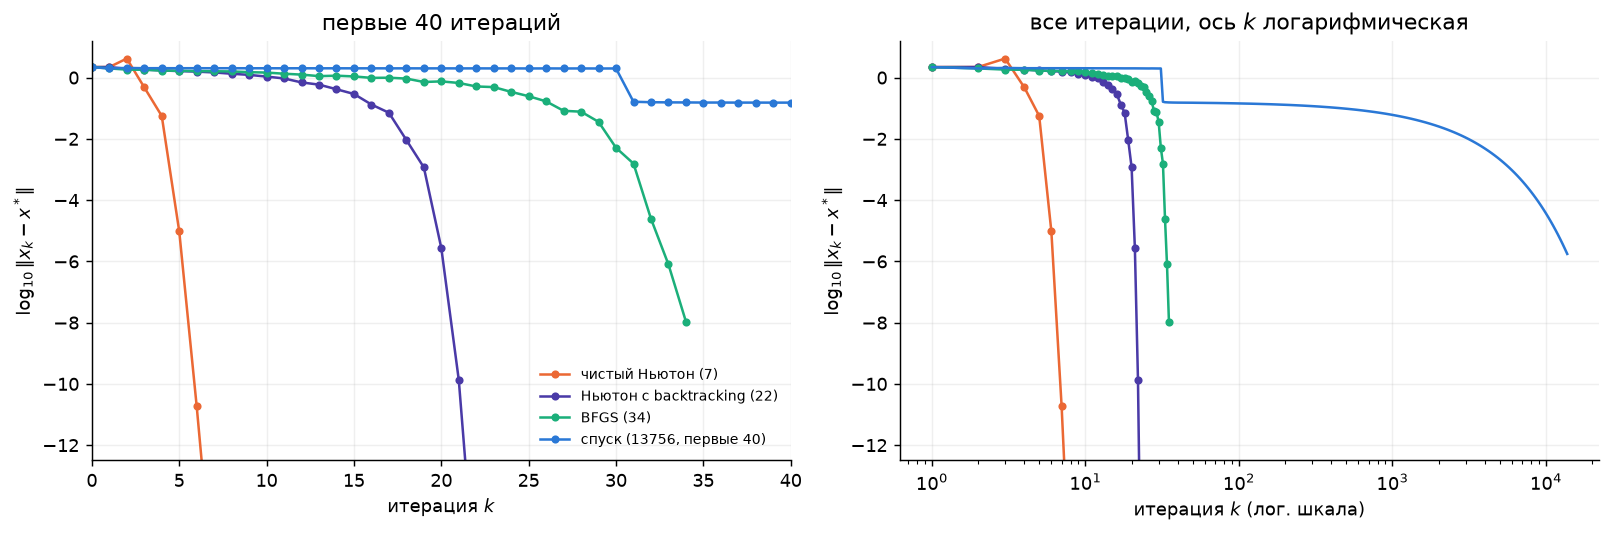

In [11]:
t0 = time.perf_counter(); x_g, k_g, path_g = gd(rosen, rosen_grad, X0_ROSEN); t_gd = time.perf_counter() - t0
err_g = np.linalg.norm(path_g - 1, axis=1)
print(f"спуск с backtracking: {k_g} итераций (в конспекте 13 756), {t_gd:.2f} с")
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.2))
plot_errors([err_n, err_d, err_b, err_g[:41]], [f"чистый Ньютон ({k_n})", f"Ньютон с backtracking ({k_d})", f"BFGS ({k_b})", f"спуск ({k_g}, первые 40)"], ax=ax1)
ax1.set(xlim=(0, 40), ylim=(-12.5, 1.2), title="первые 40 итераций")
plot_errors([err_n, err_d, err_b, err_g], ax=ax2, logx=True); ax2.set(ylim=(-12.5, 1.2), title="все итерации, ось $k$ логарифмическая")
plt.tight_layout(); plt.show()

## 5. Гаусс–Ньютон: почти Ньютон для суммы квадратов

### 5.1. Структура нелинейного МНК

Подгонка модели к данным — минимизация суммы квадратов невязок:

$$
f(x)=\tfrac12\lVert r(x)\rVert^2=\tfrac12\sum_{i=1}^m r_i(x)^2,\qquad r_i(x)=\varphi(t_i;x)-y_i .
$$

Обозначим $J(x)$ — матрицу Якоби невязок, $J_{ij}=\partial r_i/\partial x_j$ (размер $m\times n$). По цепному правилу

$$
\nabla f=J^\top r,\qquad
\nabla^2f=J^\top J+\sum_{i=1}^m r_i\,\nabla^2r_i .
$$

Первый член гессиана — $J^\top J$ — собирается из тех же первых производных, что и градиент: он **бесплатен**. Второй требует гессианов всех невязок — дорого — и пропорционален самим невязкам $r_i$.

### 5.2. Шаг Гаусса–Ньютона

Отбросим второй член: $\nabla^2f\approx J^\top J$. Получаем **метод Гаусса–Ньютона** (*Gauss–Newton*):

$$
\boxed{\;J_k^\top J_k\,p_k=-J_k^\top r_k\;}
$$

Второе прочтение, как в §2.2: это нормальные уравнения линейного МНК $\min_p\lVert J_kp+r_k\rVert^2$. То есть на каждом шаге мы **линеаризуем невязку** $r(x_k+p)\approx r_k+J_kp$ и решаем линейную задачу подгонки — ту самую, из лекции 1 (§7.1), через `np.linalg.lstsq`, без нормальных уравнений и без единой второй производной. Если невязки линейны (линейный МНК), шаг Гаусса–Ньютона — точный ответ за одну итерацию.

### 5.3. Когда он хорош: малые невязки

Ошибка модели Гаусса–Ньютона — отброшенный член $S(x)=\sum r_i\nabla^2r_i$. В решении $x^\ast$ он мал, если малы невязки (данные почти без шума) или невязки почти линейны. Тогда $J^\top J\approx\nabla^2f$, и метод сходится почти как Ньютон; в общем случае — линейно, с множителем порядка $\lVert S^\ast\rVert/\lVert J^{\ast\top}J^\ast\rVert$.

Синус из ДЗ 2 в решении $x^\ast=(2.1014,\ 2.9967,\ 0.7003)$: собственные числа $J^\top J$ — $17.6,\ 31.1,\ 1935.6$, а полного гессиана — $17.9,\ 31.1,\ 1927.3$. Отличие меньше $2\,\%$: шум $0.2$ при амплитуде $2$ — малые невязки. Гаусс–Ньютон из $(1,3,0)$: $7$ итераций, ошибки $1.3\to0.83\to0.45\to0.047\to0.0018\to3\cdot10^{-5}\to10^{-6}$, хвост отношений $\approx0.02$ — линейная сходимость, но с множителем, который на глаз не отличить от обрыва.

<img src="img/07_gn_sine.png" width="900" alt="подгонка синуса из ДЗ 2: данные и кривые Гаусса–Ньютона и Ньютона (нулевая амплитуда); справа ошибки Гаусса–Ньютона и градиентного спуска">

### 5.4. Почему Ньютон ушёл в нуль, а Гаусс–Ньютон — нет

У модели $x_1\sin(x_2t+x_3)$ есть стационарные точки с $x_1=0$: при нулевой амплитуде производные по частоте и фазе обращаются в нуль автоматически, а производная по амплитуде зануляется, когда $\sin(x_2t+x_3)$ ортогонален данным. Таких точек бесконечно много, и из $(1,3,0)$ полный гессиан (с членом $S$, который вдали от решения *не* мал) ведёт Ньютона именно туда: нуль градиента найден, $f=\tfrac12\lVert y\rVert^2$, модель бесполезна.

У Гаусса–Ньютона такого соблазна нет: $J^\top J\succeq0$ всегда, поэтому $g^\top p=-r^\top J(J^\top J)^{-1}J^\top r\le0$ — **шаг Гаусса–Ньютона всегда направление спуска** (при полном столбцовом ранге $J$). Метод не может подняться к точке с большим $f$; седловые модели ему недоступны по построению. Это и есть выигрыш от структуры: отброшенный член не только дорог, но и вреден вдали от решения.

### 5.5. Левенберг–Марквардт

Когда $J$ теряет ранг (как при $x_1=0$: два столбца нулевые) или шаг слишком велик, помогает регуляризация из §3.4:

$$
(J_k^\top J_k+\lambda_kI)\,p_k=-J_k^\top r_k .
$$

При $\lambda\to0$ это Гаусс–Ньютон, при $\lambda\to\infty$ — короткий градиентный шаг; $\lambda_k$ увеличивают после неудачного шага и уменьшают после удачного. Это **метод Левенберга–Марквардта** (*Levenberg–Marquardt*) — стандарт для подгонки кривых; в SciPy — `scipy.optimize.least_squares(..., method="lm")`: на синусе $7$ вычислений невязки, тот же ответ. Левенберг–Марквардт — доверительная область для МНК, и в лекции 6 мы увидим его с этой стороны.

### 5.6. Локальность никуда не делась

Задача по-прежнему невыпукла: из 20 случайных стартов ДЗ 2 демпфированный Гаусс–Ньютон приходит к глобальному $f^\ast=1.1393$ в $12$ случаях, остальные — в локальные минимумы с другой частотой. Быстрый локальный метод не отменяет мультистарта из ДЗ 2; он делает каждый старт дешёвым.

**Одной строкой.** Для суммы квадратов половина гессиана бесплатна; Гаусс–Ньютон берёт её одну, получает всегда-спуск и почти ньютоновскую скорость при малых невязках, а Левенберг–Марквардт страхует его регуляризацией.

### Демо (c). Гаусс–Ньютон на синусе из ДЗ 2

Раздел 5 конспекта, упражнение 11.7. **Что проверяем.** Из старта $(1,3,0)$: Гаусс–Ньютон — $7$ итераций к $x^\ast=(2.1014,\,2.9967,\,0.7003)$, $f^\ast=1.1393$; спуск с backtracking — $731$ итерация туда же; чистый Ньютон — к стационарной точке с $x_1=0$ (нулевая амплитуда, $f=\tfrac12\lVert y\rVert^2\approx64$). В $x^\ast$ собственные числа $J^\top J$ и полного гессиана отличаются меньше чем на $2\,\%$ — невязки малы, и отброшенный член $\sum r_i\nabla^2r_i$ почти не влияет.

In [12]:
x_gn, k_gn, path_gn = gauss_newton(resid, jac, X0_SINE)
x_gds, k_gds, path_gds = gd(f_s, grad_s, X0_SINE)
x_nw, k_nw, path_nw = newton(grad_s, hess_s, X0_SINE, tol=1e-6)
print(f"Гаусс–Ньютон: {k_gn} итераций (в конспекте 7),  x* = {x_gn.round(4)},  f* = {f_s(x_gn):.4f} (в конспекте 1.1393)")
print(f"спуск:        {k_gds} итераций (в конспекте 731), x  = {x_gds.round(4)},  f  = {f_s(x_gds):.4f}")
print(f"Ньютон:       {k_nw} итераций,                 x  = {x_nw.round(4)},  f  = {f_s(x_nw):.1f},  |grad f| = {np.linalg.norm(grad_s(x_nw)):.1e}  <- стационарная точка с x1 = 0")
lamJ, lamH = np.linalg.eigvalsh(jac(x_gn).T @ jac(x_gn)), np.linalg.eigvalsh(hess_s(x_gn))
print("собственные числа J^T J в x*:", lamJ.round(2), "  полного гессиана:", lamH.round(2), f"  относительная разница до {np.max(np.abs(lamJ - lamH) / lamH):.1%}")
err_gn = np.linalg.norm(path_gn - x_gn, axis=1)
print("ошибки Гаусса–Ньютона:", np.array2string(err_gn, precision=6), " отношения:", np.array2string(err_gn[1:] / err_gn[:-1], precision=3))

Гаусс–Ньютон: 7 итераций (в конспекте 7),  x* = [2.1014 2.9967 0.7003],  f* = 1.1393 (в конспекте 1.1393)
спуск:        731 итераций (в конспекте 731), x  = [2.1014 2.9967 0.7003],  f  = 1.1393
Ньютон:       9 итераций,                 x  = [-0.      3.8658 -6.4737],  f  = 64.4,  |grad f| = 1.2e-09  <- стационарная точка с x1 = 0
собственные числа J^T J в x*: [  17.57   31.05 1935.56]   полного гессиана: [  17.89   31.12 1927.31]   относительная разница до 1.8%
ошибки Гаусса–Ньютона: [1.305161e+00 8.297955e-01 4.548437e-01 4.714325e-02 1.842978e-03
 3.304049e-05 7.004102e-07 0.000000e+00]  отношения: [0.636 0.548 0.104 0.039 0.018 0.021 0.   ]


Почему Ньютон уходит в нуль: при $x_1=0$ столбцы $J$ для частоты и фазы нулевые, а $\nabla f=J^\top r$ зануляется, когда $\sin(x_2t+x_3)\perp y$ — таких стационарных точек бесконечно много, и полный гессиан вдали от решения ведёт к ним. У Гаусса–Ньютона $J^\top J\succeq0$, и его шаг — всегда направление спуска: проверяем знак $g^\top p$ вдоль пути обоих методов.

In [13]:
for name, path, use_gn in (("Гаусс–Ньютон", path_gn, True), ("Ньютон", path_nw, False)):
    signs = []
    for x in path[:-1]:
        g = grad_s(x)
        p = np.linalg.lstsq(jac(x), -resid(x), rcond=None)[0] if use_gn else -np.linalg.solve(hess_s(x), g)
        signs.append(g @ p < 0)
    print(f"{name:13s}: направление спуска на итерациях {np.array(signs).astype(int)}  (1 — спуск, 0 — подъём)")
print("Левенберг–Марквардт (scipy.optimize.least_squares, method='lm'):", end=" ")
r_lm = least_squares(resid, X0_SINE, jac=jac, method="lm")
print(f"{r_lm.nfev} вычислений невязки, x = {r_lm.x.round(4)}")

Гаусс–Ньютон : направление спуска на итерациях [1 1 1 1 1 1 1]  (1 — спуск, 0 — подъём)
Ньютон       : направление спуска на итерациях [0 1 1 0 0 0 0 0 0]  (1 — спуск, 0 — подъём)
Левенберг–Марквардт (scipy.optimize.least_squares, method='lm'): 7 вычислений невязки, x = [2.1014 2.9967 0.7003]


**Локальность никуда не делась.** Запускаем демпфированный Гаусс–Ньютон из 20 стартов ДЗ 2 (те же `starts`): к глобальному $f^\ast=1.1393$ должны прийти $12$ из $20$, остальные — к локальным минимумам с другой частотой. Каждый старт стоит десятки итераций, а не сотни — мультистарт из ДЗ 2 становится дешёвым.

к глобальному минимуму пришли 12 из 20 стартов (в конспекте 12);  итераций: медиана 12, максимум 200
итоговые f по стартам: [ 1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14  1.14 60.14 61.5  61.5  61.5  61.69 64.22 64.25
 64.25]


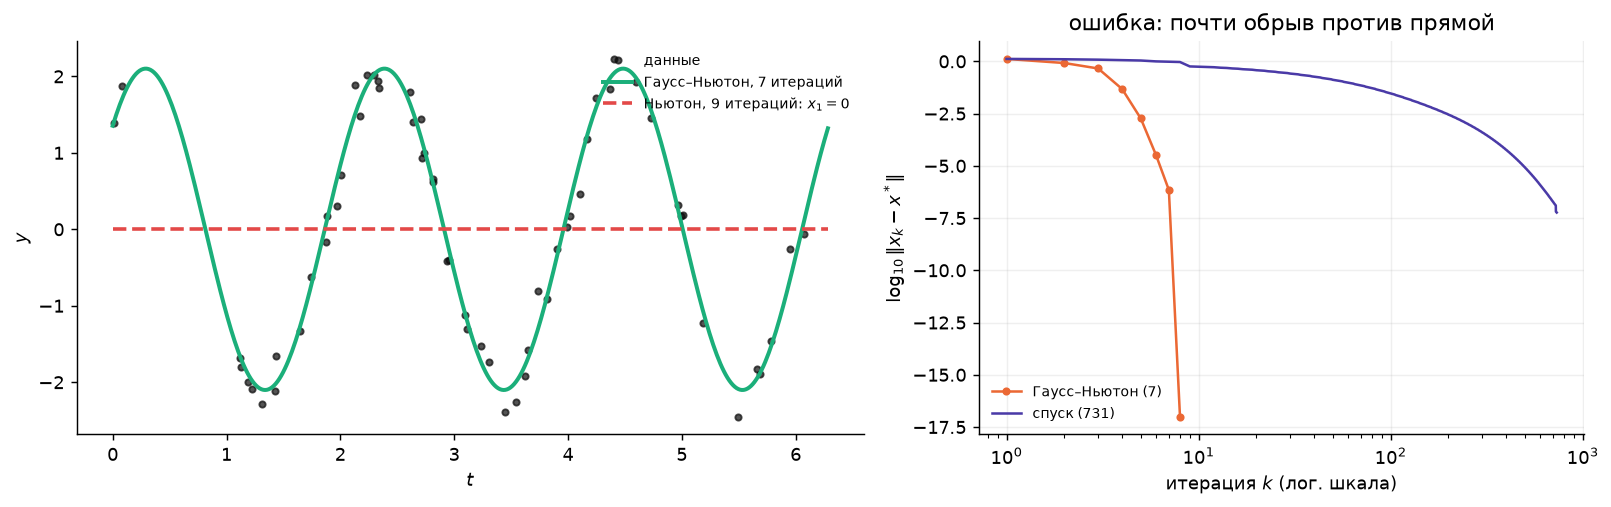

In [14]:
finals = []
for s0 in starts:
    xs, ks, _ = gauss_newton(resid, jac, s0, damped=True, maxit=200)
    finals.append((f_s(xs), ks))
finals = np.array(finals)
n_global = np.sum(np.abs(finals[:, 0] - f_s(x_gn)) < 1e-6)
print(f"к глобальному минимуму пришли {n_global} из {len(starts)} стартов (в конспекте 12);  итераций: медиана {np.median(finals[:, 1]):.0f}, максимум {finals[:, 1].max():.0f}")
print("итоговые f по стартам:", np.array2string(np.sort(finals[:, 0]), precision=2, max_line_width=120))

tt = np.linspace(0, 2 * np.pi, 400)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12.5, 4.0), gridspec_kw={"width_ratios": [1.3, 1]})
ax1.plot(t, y, "o", ms=3.5, color=INK, alpha=0.7, label="данные")
ax1.plot(tt, x_gn[0] * np.sin(x_gn[1] * tt + x_gn[2]), color=AQUA, lw=2.2, label=f"Гаусс–Ньютон, {k_gn} итераций")
ax1.plot(tt, x_nw[0] * np.sin(x_nw[1] * tt + x_nw[2]), "--", color=RED, lw=2, label=f"Ньютон, {k_nw} итераций: $x_1=0$")
ax1.set(xlabel="$t$", ylabel="$y$"); ax1.legend(fontsize=8, loc="upper right"); ax1.grid(False)
plot_errors([err_gn, np.linalg.norm(path_gds - x_gn, axis=1)], [f"Гаусс–Ньютон ({k_gn})", f"спуск ({k_gds})"], ax=ax2, logx=True)
ax2.set_title("ошибка: почти обрыв против прямой"); plt.tight_layout(); plt.show()

## 6. Сравнение: три задачи, пять методов

| Метод | Что нужно от $f$ | Цена итерации | Сходимость | Розенброк из $(-1.2,1)$ |
|---|---|---|---|---|
| градиентный спуск, backtracking | $\nabla f$ | $O(n)$ | линейная, $\propto\kappa$ | $13\,756$ |
| Ньютон | $\nabla f$, $\nabla^2f$, решение системы | $O(n^3)$ | квадратичная вблизи; вдали может уйти | $7$ (демпфированный — $22$) |
| BFGS | $\nabla f$ | $O(n^2)$ | сверхлинейная | $34$ (SciPy — $33$) |
| L-BFGS, память $m$ | $\nabla f$ | $O(mn)$ | линейная, множитель много лучше спуска | $36$ (SciPy) |
| Гаусс–Ньютон / Левенберг–Марквардт | $r$, $J$ | $O(mn^2)$ | почти квадратичная при малых невязках | синус: $7$ против $731$ у спуска |

**Биография цепи.** Одна и та же выпуклая квадратичная задача, $N=40$, $80$ переменных, останов по $\lVert\nabla E\rVert\le10^{-6}$:

| Лекция | Метод | Итераций | Что нового |
|---|---|---|---|
| 1 | солвер как чёрный ящик | — | постановка задачи |
| 4 | градиентный спуск, шаг $1/L$ | $10\,575$ | $\propto\kappa=681$ |
| 5 | Ньютон | $1$ | модель точна: один `np.linalg.solve` |
| 5 | BFGS, точный шаг | $20$ | не больше числа различных собственных чисел гессиана |
| 5 | L-BFGS, память 5 (SciPy) | $75$ | $O(mn)$ памяти — пригоден и при $N=10^5$ |

<img src="img/08_chain_methods.png" width="900" alt="цепь: число итераций градиентного спуска, BFGS и L-BFGS в зависимости от числа грузов N; Ньютон — одна итерация">

Спуск растёт как $N^2$ (за $\kappa$), BFGS — как $N/2$ (точный поиск на квадратичной), L-BFGS — примерно как $N$, Ньютон — константа. При $N=160$ спуск делает $155\,943$ итерации и около $10$ секунд, Ньютон — миллисекунды. Но Ньютон хранит и решает систему $2N\times2N$: при $N=10^5$ останутся только L-BFGS и спуск.

**Одной строкой.** Чем больше кривизны знает метод, тем меньше итераций и дороже каждая; выбор — между $O(n)$, $O(n^2)$ и $O(n^3)$ за шаг.

### Демо (d). Биография цепи

Раздел 6 конспекта, упражнение 11.9. **Что проверяем** на цепи $N=40$ (старт — прямая между концами, останов $\lVert\nabla E\rVert\le10^{-6}$): спуск с шагом $1/L$ — $10\,575$ итераций (лекция 4); Ньютон — одна итерация, то есть `np.linalg.solve`; BFGS с точным шагом — $20$ итераций (не больше числа различных собственных чисел $H$, их у $\operatorname{diag}(DK,DK)$ ровно $N=40$; здесь из-за симметрии старта хватает $N/2$); `L-BFGS-B` с памятью 5 — $75$.

In [15]:
L = np.linalg.eigvalsh(H_chain)[-1]
t0 = time.perf_counter(); v_gd, k_gd, _ = gd(energy, grad_E, v0_chain, alpha=1 / L); t_gd = time.perf_counter() - t0
v_nt = v0_chain - np.linalg.solve(H_chain, grad_E(v0_chain))                       # один шаг Ньютона
v_bq, k_bq, _, _ = bfgs(energy, grad_E, v0_chain, Q=H_chain)
r_l = minimize(energy, v0_chain, jac=grad_E, method="L-BFGS-B", options={"gtol": 1e-6, "maxcor": 5})
print(f"спуск, шаг 1/L:        {k_gd} итераций ({t_gd:.2f} с; в конспекте 10 575),  |v - v*| = {np.linalg.norm(v_gd - v_star):.1e}")
print(f"Ньютон:                1 итерация,                              |v - v*| = {np.linalg.norm(v_nt - v_star):.1e}")
print(f"BFGS, точный шаг:      {k_bq} итераций (в конспекте 20),              |v - v*| = {np.linalg.norm(v_bq - v_star):.1e}")
print(f"L-BFGS-B, память 5:    {r_l.nit} итераций (в конспекте 75),              |v - v*| = {np.linalg.norm(r_l.x - v_star):.1e}")
print(f"различных собственных чисел H: {len(np.unique(np.linalg.eigvalsh(H_chain).round(8)))}  (N = 40)")

спуск, шаг 1/L:        10575 итераций (0.13 с; в конспекте 10 575),  |v - v*| = 2.4e-06
Ньютон:                1 итерация,                              |v - v*| = 3.4e-14
BFGS, точный шаг:      20 итераций (в конспекте 20),              |v - v*| = 5.1e-14
L-BFGS-B, память 5:    75 итераций (в конспекте 75),              |v - v*| = 2.4e-04
различных собственных чисел H: 40  (N = 40)


**Как BFGS ломается без правильного линейного поиска.** Тот же BFGS, но длина шага — одним лишь backtracking от $\alpha=1$ вниз. На цепи он не сходится за $2\,000$ итераций (и за $10\,000$ тоже — проверьте, подняв `maxit`): крошечные принятые шаги дают пары $(s,y)$, которые портят $H_k$, направление $p_k$ раздувается, шаг снова крошечный. Печатаем длины принятых шагов в конце — они порядка $10^{-9}$: $\alpha$ опустился до $2^{-35}$. Условие Вольфе, которое чинит это, — лекция 6; SciPy с ним сходится за $66$ итераций.

In [16]:
v_bb, k_bb, path_bb, nfev_bb = bfgs(energy, grad_E, v0_chain, maxit=2000)
steps = np.linalg.norm(np.diff(path_bb, axis=0), axis=1)
print(f"BFGS с backtracking: {'НЕ сошёлся' if k_bb >= 2000 else 'сошёлся'} за {k_bb} итераций, {nfev_bb} вычислений E ({nfev_bb / max(k_bb, 1):.0f} на итерацию);  |grad E| = {np.linalg.norm(grad_E(v_bb)):.1e}")
print("длины последних пяти принятых шагов |s_k|:", np.array2string(steps[-5:], formatter={"float_kind": "{:.1e}".format}), "  (2^-35 от направления)")
r_sb = minimize(energy, v0_chain, jac=grad_E, method="BFGS", options={"gtol": 1e-6})
print(f"scipy BFGS (линейный поиск по Вольфе): {r_sb.nit} итераций, {r_sb.nfev} вычислений E")

BFGS с backtracking: НЕ сошёлся за 2000 итераций, 70719 вычислений E (35 на итерацию);  |grad E| = 3.5e-06
длины последних пяти принятых шагов |s_k|: [0.0e+00 0.0e+00 0.0e+00 0.0e+00 0.0e+00]   (2^-35 от направления)
scipy BFGS (линейный поиск по Вольфе): 66 итераций, 83 вычислений E


**Биография по $N$.** Для $N=10,20,40,80$ — число итераций спуска, BFGS с точным шагом и L-BFGS; Ньютон всегда $1$. Спуск растёт как $\kappa\sim N^2$, BFGS — как $N/2$, L-BFGS — примерно как $N$. Картинка 08 конспекта продолжает таблицу до $N=160$ (спуск там — $155\,943$ итерации и $10$ секунд).

In [17]:
print(" N    κ        спуск 1/L   BFGS точный   L-BFGS m=5   Ньютон")
for N_ in (10, 20, 40, 80):
    e_, g_, H_, b_, v0_, _ = make_chain(N_)
    lam_ = np.linalg.eigvalsh(H_)
    _, kg_, _ = gd(e_, g_, v0_, alpha=1 / lam_[-1], maxit=100_000)
    _, kb_, _, _ = bfgs(e_, g_, v0_, Q=H_)
    rl_ = minimize(e_, v0_, jac=g_, method="L-BFGS-B", options={"gtol": 1e-6, "maxcor": 5})
    print(f"{N_:3d}  {lam_[-1] / lam_[0]:7.1f}   {kg_:9d}   {kb_:11d}   {rl_.nit:10d}        1")

 N    κ        спуск 1/L   BFGS точный   L-BFGS m=5   Ньютон
 10     48.4         779             5           12        1
 20    178.1        2825            10           26        1
 40    680.6       10575            20           75        1


 80   2658.4       40388            40          144        1


Одна и та же задача: $10\,575\to75\to20\to1$. Чем больше кривизны знает метод, тем меньше итераций — и тем дороже каждая: $O(n)$ у спуска, $O(mn)$ у L-BFGS, $O(n^2)$ у BFGS, $O(n^3)$ у Ньютона. При $N=10^5$ из таблицы останутся только первые два.

## 7. Что это даёт численно

- **Диагноз по графику** $\log\lVert\nabla f(x_k)\rVert$: прямая — метод первого порядка, читайте $\kappa$ (Л4, §5); кривая загибается всё круче — квази-Ньютон работает; обрыв — ньютоновская область. Горб в начале у Ньютона — модель врала, нужен линейный поиск.
- **Стационарная точка — ещё не минимум**, и Ньютон этого не проверяет: собственные числа гессиана в найденной точке (Л4, §3) — обязательный финальный шаг.
- **`scipy.optimize.minimize`**: `BFGS` по умолчанию (градиент — аналитический через `jac=` или конечные разности); `L-BFGS-B` — когда переменных тысячи; `Newton-CG` и `trust-exact` — когда есть гессиан; на Розенброке `Newton-CG` сделал $85$ итераций — внутри него система решается приближённо, сопряжёнными градиентами (лекция 6).
- **Подгонка кривых** — всегда `scipy.optimize.least_squares` (Левенберг–Марквардт или доверительная область), а не `minimize` суммы квадратов: структура $J^\top J$ стоит нескольких порядков скорости.
- **ДЗ 3**: вы напишете спуск, демпфированного Ньютона, BFGS и Гаусса–Ньютона сами и воспроизведёте числа этой лекции на Розенброке, цепи и синусе.

## 8. Итоги лекции

1. Шаг Ньютона — минимум квадратичной модели и нуль линеаризованного градиента; длина шага задаётся моделью, координаты метод не замечает (раздел 2).
2. Вблизи минимума ошибка возводится в квадрат: $\lVert e_{k+1}\rVert\le\frac M{2m}\lVert e_k\rVert^2$ — число верных цифр удваивается, $7$ итераций на Розенброке (раздел 3).
3. Вдали модель врёт: Ньютон приходит в сёдла и максимумы ($36\,\%$ стартов на Химмельблау), может шагнуть вверх при индефинитном гессиане; демпфирование чинит это за $22$ итерации (раздел 3).
4. Секущее уравнение $B_{k+1}s_k=y_k$ измеряет кривизну разностью градиентов; BFGS — обновление ранга два, сохраняющее $\succ0$ при $s^\top y>0$; сходимость сверхлинейная, $34$ итерации без единой второй производной (раздел 4).
5. L-BFGS хранит $m$ пар вместо матрицы: $O(mn)$ — метод для миллиона переменных (раздел 4).
6. Для суммы квадратов $J^\top J$ — бесплатная половина гессиана: Гаусс–Ньютон — всегда спуск, $7$ итераций против $731$; Левенберг–Марквардт — его регуляризация (раздел 5).
7. На цепи: $10\,575\to20\to1$ — цена и число итераций меняются местами (раздел 6).

## 9. Что дальше

**Лекция 6** — глобализация: условия Армихо и Вольфе, почему BFGS без Вольфе ломается, доверительная область и Левенберг–Марквардт как её частный случай, метод сопряжённых градиентов — то, что внутри `Newton-CG`. **Лекция 7** — как считать производные: конечные разности и алгоритмическое дифференцирование, CasADi всерьёз.

**ДЗ 3** выдаётся сегодня, срок — 21 октября: градиентный спуск, Ньютон, BFGS и Гаусс–Ньютон — реализация и сравнение на задачах этой лекции ([карточка](../../homeworks/hw03.md), [ноутбук](../../homeworks/hw03.ipynb)). **ДЗ 2** — срок сегодня.

**Литература к лекции.** Diehl, гл. 5–6 (Newton-type methods, local convergence); Nocedal & Wright, §3.3 (Newton), гл. 6 (quasi-Newton, BFGS), §7.2 (L-BFGS), §10.1–10.3 (least squares, Gauss–Newton, Levenberg–Marquardt); Boyd & Vandenberghe, §9.5 (Newton's method); Поляк, гл. 1 (метод Ньютона и квазиньютоновские методы).

## 10. Семинар: свой Ньютон и BFGS против SciPy

Весь семинар — за ноутбуком [`seminar05.ipynb`](seminar05.ipynb) (~30 минут), только numpy и scipy. Пишем методы сами по формулам лекции, каждое число сверяем с конспектом и со SciPy.

| Мин | Часть |
|-----|------|
| 12 | **Часть 1 — Ньютон.** Чистый Ньютон за десять строк: $7$ итераций, таблица ошибок, выброс итерации 2 и область индефинитности; `minimize(method="Newton-CG")` — $85$ итераций, вопрос залу «почему больше?»; добавляем backtracking — $22$ |
| 18 | **Часть 2 — BFGS и Гаусс–Ньютон.** Секущее уравнение на квадратичной: два обновления — и $H_2=Q^{-1}$ (упражнение 11.5); BFGS на Розенброке — $34$ итерации и $54$ вызова против $33$ и $40$ у SciPy; соревнование «из какого старта BFGS сойдётся быстрее всех?»; Гаусс–Ньютон на синусе ДЗ 2 — $7$ против $731$ у спуска и против Ньютона в $x_1=0$ |

Дома: 11.0–11.4, 11.6, 11.8–11.10; 11.5 и 11.7 — повторение семинара. Затем демонстрации (a)–(d) в конспекте-ноутбуке или `demo05.ipynb`.

## 11. Упражнения

Для разбора на занятии и самостоятельно. У каждой задачи курсивом — её суть одной фразой. Подробный разбор с проверкой кодом — ноутбук [`exercises05.ipynb`](exercises05.ipynb), краткие ответы — [`exercises05.md`](exercises05.md).

**11.0. Разминка — счёт руками.** Шесть пунктов по минуте. *Суть: шаг Ньютона, секущая и структура МНК — на бумаге, без компьютера.*

- (а) $f(x)=\tfrac12(x_1^2+9x_2^2)-x_1-9x_2$. Сделайте один шаг Ньютона из $(0,0)$. Куда попали? Проверьте, что $\nabla f=0$.
- (б) $\sqrt2$ методом Ньютона для $F(x)=x^2-2$ из $x_0=1$: выпишите $x_1,x_2,x_3$ и число верных цифр каждого.
- (в) Метод секущих для $f(x)=x^4$: по точкам $x_0=1$, $x_1=0.5$ оцените $f''$ через $y/s$ и сравните с $f''(0.5)=3$ и $f''(1)=12$.
- (г) $f=\tfrac12\lVert r\rVert^2$, $r(x)=(x_1-1,\ x_1x_2)$. Выпишите $J$, $J^\top J$ и полный $\nabla^2f$. Какой член отбрасывает Гаусс–Ньютон и когда он равен нулю?
- (д) Повторение Л4: $\kappa$ гессиана Розенброка в $(1,1)$ по следу и определителю ($\operatorname{tr}=1002$, $\det=400$). Почему это число не влияет на метод Ньютона?
- (е) $H=\operatorname{diag}(1,-1)$. Для $g=(1,0)$ и для $g=(0,1)$ найдите $p=-H^{-1}g$ и знак $g^\top p$: спуск или подъём?

**11.1. Два прочтения шага Ньютона.** *Суть: минимум модели и нуль линеаризованного градиента — одна формула; координаты она не видит.*

- (а) Покажите, что $\nabla m_k(p)=0$ и линеаризация $\nabla f(x_k+p)\approx0$ дают один и тот же $p$.
- (б) Докажите аффинную инвариантность: при $x=Au$ шаги связаны как $A\tilde p=p$ (§2.4).
- (в) Градиентный спуск такой инвариантностью не обладает: покажите на $f=\tfrac12(x_1^2+25x_2^2)$ и замене $u_2=5x_2$, что шаг $-\alpha\nabla\tilde f$ в $u$ не равен пересчитанному шагу $-\alpha\nabla f$ в $x$.

**11.2. Квадратичная сходимость** (домашняя). *Суть: ошибка Ньютона — это ошибка модели, а она квадратична.*

- (а) Проведите доказательство §3.1 подробно, с указанием, где используется липшицевость гессиана и где — $\nabla^2f\succeq mI$.
- (б) Для Розенброка оцените $M$ (норму производной гессиана по $x$ в окрестности $(1,1)$) и $m=\lambda_{\min}=0.3994$. Чему равен радиус шара, в котором теорема гарантирует сходимость?
- (в) Сравните $C=M/2m$ с измеренными $C_k=\lVert e_{k+1}\rVert/\lVert e_k\rVert^2$ из таблицы §3.2. Почему оценка настолько пессимистична?

**11.3. Сломай метод.** *Суть: у Ньютона есть порог старта, за которым он расходится; демпфирование снимает порог.*

- (а) Для $f=\ln\cosh x$ выпишите итерацию и найдите численно порог $x_0^\ast$, при котором $x_1=-x_0$ (2-цикл). Ответ $\approx1.0886$.
- (б) То же для решения $\arctan x=0$ методом Ньютона: порог $\approx1.3917$.
- (в) Объясните по картинке §2.3, почему ниже порога метод сходится, а выше — расходится.
- (г) Добавьте к шагу backtracking по Армихо для $f=\ln\cosh x$. Сходится ли метод из $x_0=5$? За сколько итераций?

**11.4. Ньютон на седловой модели и демпфирование.** *Суть: при индефинитном гессиане «минимум модели» — седло, и шаг может вести вверх.*

- (а) $f=x_1^2-x_2^2+x_2^4/4$: найдите стационарные точки и их тип. Покажите, что из любой точки с $x_2^2<1/3$ шаг Ньютона ведёт в седло $(0,0)$.
- (б) Для Розенброка проверьте: $\det\nabla^2f<0\iff x_2>x_1^2+0.005$. Приведите точку, где $g^\top p>0$ для ньютоновского $p$.
- (в) Почему вблизи минимума демпфированный Ньютон принимает $\alpha=1$ и сохраняет квадратичную сходимость? Подсказка: Армихо с $c<1/2$ и квадратичная модель, которая точна в пределе.

**11.5. BFGS руками.** *Суть: два обновления на квадратичной $2\times2$ восстанавливают $Q^{-1}$ целиком.* Разбирается на семинаре.

- (а) $f=\tfrac12(x_1^2+50x_2^2)$, $x_0=(50,1)$, $H_0=I$. Первый шаг — градиентный с точным $\alpha=\lVert g\rVert^2/g^\top Qg$ (Л4, §4.4). Выпишите $s_0$, $y_0=Qs_0$ и проверьте $s_0^\top y_0>0$.
- (б) Вычислите $H_1$ по формуле BFGS и проверьте $H_1y_0=s_0$.
- (в) Сделайте второй шаг $p_1=-H_1g_1$ с точным поиском и получите $H_2$. Убедитесь, что $H_2=Q^{-1}$ и что $x_2=0$.

**11.6. Свойства обновления BFGS** (домашняя). *Суть: симметрия, секущее уравнение и положительная определённость — всё проверяется подстановкой.*

- (а) Проверьте $H_{k+1}y_k=s_k$ прямой подстановкой в формулу §4.3.
- (б) Докажите: если $H_k\succ0$ и $s_k^\top y_k>0$, то $H_{k+1}\succ0$. Подсказка: для любого $z\ne0$ запишите $z^\top H_{k+1}z=w^\top H_kw+\rho_k(s_k^\top z)^2$ с $w=z-\rho_k(s_k^\top z)y_k$ и разберите случай $w=0$.
- (в) Почему на выпуклой функции $s^\top y>0$ при любом шаге, а на невыпуклой — нет? Приведите пример с $f=-x^2$.

**11.7. Гаусс–Ньютон.** *Суть: половина гессиана бесплатна, всегда $\succeq0$ и даёт спуск; вторая половина вдали от решения вредна.* Разбирается на семинаре.

- (а) Выведите $\nabla f=J^\top r$ и $\nabla^2f=J^\top J+\sum r_i\nabla^2r_i$ для $f=\tfrac12\lVert r\rVert^2$.
- (б) Покажите, что шаг Гаусса–Ньютона — решение линейного МНК $\min_p\lVert Jp+r\rVert^2$, и что при полном столбцовом ранге $J$ он — направление спуска.
- (в) Для синуса $r_i=x_1\sin(x_2t_i+x_3)-y_i$ выпишите столбцы $J$. Что происходит с $J$ при $x_1=0$ и почему там стационарные точки? Почему Ньютон из $(1,3,0)$ пришёл в такую точку, а Гаусс–Ньютон — нет?
- (г) Для линейных невязок $r=Ax-b$ покажите, что один шаг Гаусса–Ньютона из любой точки даёт решение линейного МНК.

**11.8. Прочитайте график.** Три метода стартовали с $\lVert e_0\rVert=1$ и дали ошибки: (А) $0.98,\ 0.96,\ 0.94,\dots$; (Б) $0.3,\ 0.05,\ 3\cdot10^{-3},\ 10^{-5},\ 10^{-9}$; (В) $0.5,\ 0.1,\ 10^{-2},\ 10^{-4},\ 10^{-8},\ 10^{-16}$. *Суть: тип сходимости читается по отношениям соседних ошибок — повторение Л4, §6.*

- Определите тип каждой последовательности и назовите метод из сегодняшней таблицы, который так себя ведёт.
- Сколько итераций понадобится каждому, чтобы дойти до $10^{-12}$?

**11.9. Цепь: квази-Ньютон на квадратичной** (с кодом). *Суть: BFGS с точным шагом конечен на квадратичной, а без правильного линейного поиска хрупок.*

- (а) Запустите `bfgs` из `l5helpers.py` на цепи $N=10,20,40,80$ с точным шагом (`Q=H`). Сколько итераций? Почему не больше числа *различных* собственных чисел гессиана (их у $\operatorname{diag}(DK,DK)$ ровно $N$)?
- (б) Тот же метод с backtracking: для каких $N$ из $10,20,40,80$ он сходится за $10\,000$ итераций, а для каких нет? Распечатайте длины принятых шагов на последних итерациях и опишите, что сломалось.
- (в) `minimize(method="L-BFGS-B", options={"maxcor": 5})` на $N=40,80,160,400$: таблица итераций и времени против `np.linalg.solve`.

**11.10. Демпфированный Ньютон из разных стартов** (с кодом). *Суть: линейный поиск убирает выбросы, но не меняет предел.*

- (а) Запустите чистый и демпфированный Ньютон на Розенброке из 10 случайных стартов в $[-2,2]\times[-1,3]$ (`rng = np.random.default_rng(2026)`). Сравните число итераций и наибольшую ошибку по пути.
- (б) Запустите оба на Химмельблау из тех же стартов. Куда приходит каждый? Отличается ли доля минимумов у демпфированного метода?

## Вопросы для самопроверки

1. Два прочтения шага Ньютона — через модель и через систему $\nabla f=0$. Какое из них объясняет, почему метод приходит в сёдла?
2. Что именно квадратично в квадратичной сходимости и откуда в оценке берутся $M$ и $m$? Почему из оценки нельзя узнать область сходимости?
3. Почему градиентному спуску важен масштаб переменных, а методу Ньютона — нет? Какое свойство это формализует?
4. Когда шаг Ньютона — не направление спуска? Как устроено демпфирование и почему вблизи минимума оно не портит скорость?
5. Что такое секущее уравнение, сколько у него решений при $n>1$ и как BFGS выбирает одно? Какое условие на $(s,y)$ сохраняет положительную определённость?
6. Чем L-BFGS отличается от BFGS и почему это единственный метод из таблицы, пригодный при миллионе переменных?
7. Какую часть гессиана отбрасывает Гаусс–Ньютон, почему она бесплатна и почему её отсутствие делает метод всегда-спуском? Что добавляет Левенберг–Марквардт?